<a href="https://colab.research.google.com/github/Danta110/Automated-CCTV-Object-Classification-System/blob/main/Capstone_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Object Classification for automated cctv

In [ ]:

# Import neccesary Libraries and the cifar-10 dataset
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
#Load Dataset

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

class_names = [
    'Airplane',
    'Automobile',
    'Bird',
    'Cat',
    'Deer',
    'Dog',
    'Frog',
    'Horse',
    'Ship',
    'Truck'
]



170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 15s 0us/step


In [ ]:
# Normalize images
x_train = x_train / 255.0
x_test = x_test / 255.0

# One-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [ ]:
# Data Augmentation

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(x_train)

In [ ]:
# Building the CNN model
model = Sequential()
# block1
model.add(Conv2D(
    32,
    (3,3),
    padding='same',
    activation='relu',
    input_shape=(32,32,3)
))

model.add(BatchNormalization())

model.add(Conv2D(
    32,
    (3,3),
    activation='relu',
    padding='same'
))

model.add(MaxPooling2D((2,2)))

model.add(Dropout(0.25))
# block2
model.add(Conv2D(
    64,
    (3,3),
    activation='relu',
    padding='same'
))

model.add(BatchNormalization())

model.add(Conv2D(
    64,
    (3,3),
    activation='relu',
    padding='same'
))

model.add(MaxPooling2D((2,2)))

model.add(Dropout(0.30))
# block3
model.add(Conv2D(
    128,
    (3,3),
    activation='relu',
    padding='same'
))

model.add(BatchNormalization())

model.add(MaxPooling2D((2,2)))

model.add(Dropout(0.35))
#flattening layer
model.add(Flatten())
#DenseLayer
model.add(Dense(128, activation='relu'))

model.add(Dropout(0.5))

#Softmax Output layer

model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 403,882 (1.54 MB)

 Trainable params: 403,434 (1.54 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
# compile model

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
# Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [ ]:
# Train Model
history = model.fit(
    datagen.flow(x_train, y_train, batch_size=64),
    epochs=30,
    validation_data=(x_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 50s 50ms/step - accuracy: 0.2884 - loss: 1.9223 - val_accuracy: 0.4288 - val_loss: 1.5491
Epoch 2/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 32s 41ms/step - accuracy: 0.4142 - loss: 1.5954 - val_accuracy: 0.5349 - val_loss: 1.3018
Epoch 3/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 32s 41ms/step - accuracy: 0.4902 - loss: 1.4127 - val_accuracy: 0.5520 - val_loss: 1.2965
Epoch 4/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 32s 41ms/step - accuracy: 0.5400 - loss: 1.2926 - val_accuracy: 0.5140 - val_loss: 1.6268
Epoch 5/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 31s 40ms/step - accuracy: 0.5768 - loss: 1.2006 - val_accuracy: 0.6382 - val_loss: 1.0543
Epoch 6/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 32s 41ms/step - accuracy: 0.6054 - loss: 1.1227 - val_accuracy: 0.6714 - val_loss: 0.9499
Epoch 7/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 31s 40ms/step - accuracy: 0.6270 - loss: 1.0697 - val_accuracy: 0.6038 - val_loss: 1.2718
Epoch 8/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 32s 41ms/step - accuracy: 0.6481 - loss: 1.0238 - 

In [ ]:
# Evaluate the model

test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("\nTest Accuracy :", test_accuracy)
print("Test Loss     :", test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7935 - loss: 0.6086

Test Accuracy : 0.7935000061988831
Test Loss     : 0.6086340546607971


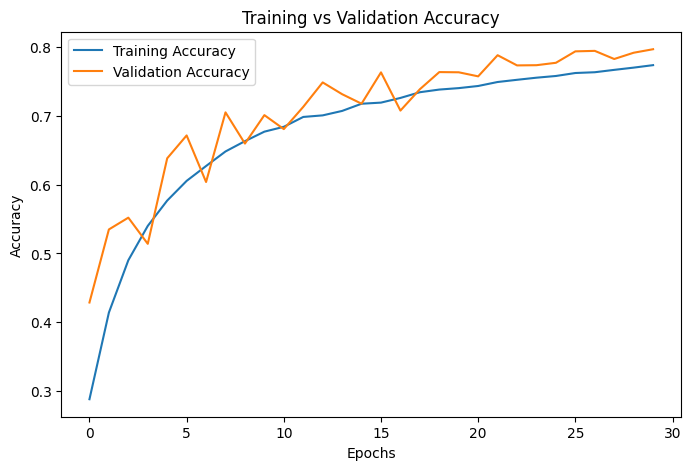

In [ ]:
# Plotting the accuracy graph

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.legend()

plt.show()

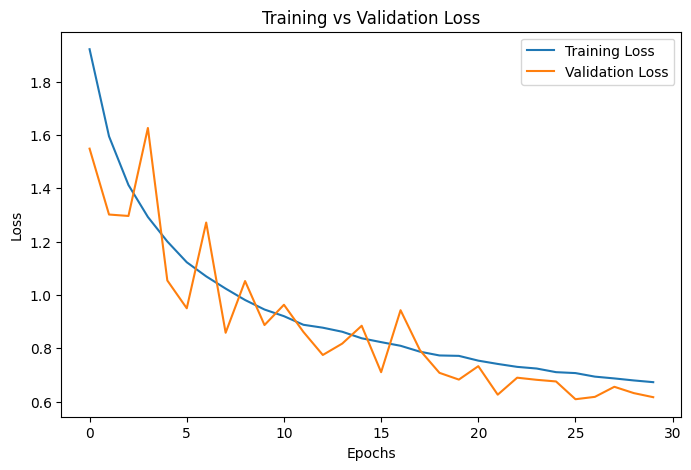

In [ ]:
# Plotting the loss graph

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()

plt.show()

In [ ]:
predictions = model.predict(x_test)

predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_test, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


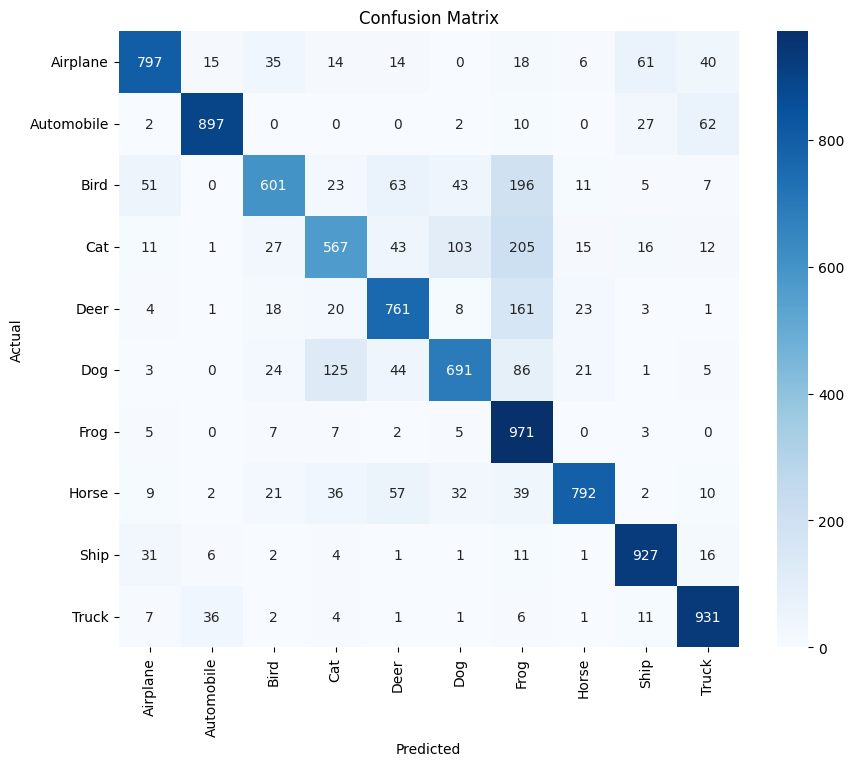

In [ ]:
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()


In [ ]:

print("\nClassification Report\n")

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=class_names
))


Classification Report

              precision    recall  f1-score   support

    Airplane       0.87      0.80      0.83      1000
  Automobile       0.94      0.90      0.92      1000
        Bird       0.82      0.60      0.69      1000
         Cat       0.71      0.57      0.63      1000
        Deer       0.77      0.76      0.77      1000
         Dog       0.78      0.69      0.73      1000
        Frog       0.57      0.97      0.72      1000
       Horse       0.91      0.79      0.85      1000
        Ship       0.88      0.93      0.90      1000
       Truck       0.86      0.93      0.89      1000

    accuracy                           0.79     10000
   macro avg       0.81      0.79      0.79     10000
weighted avg       0.81      0.79      0.79     10000



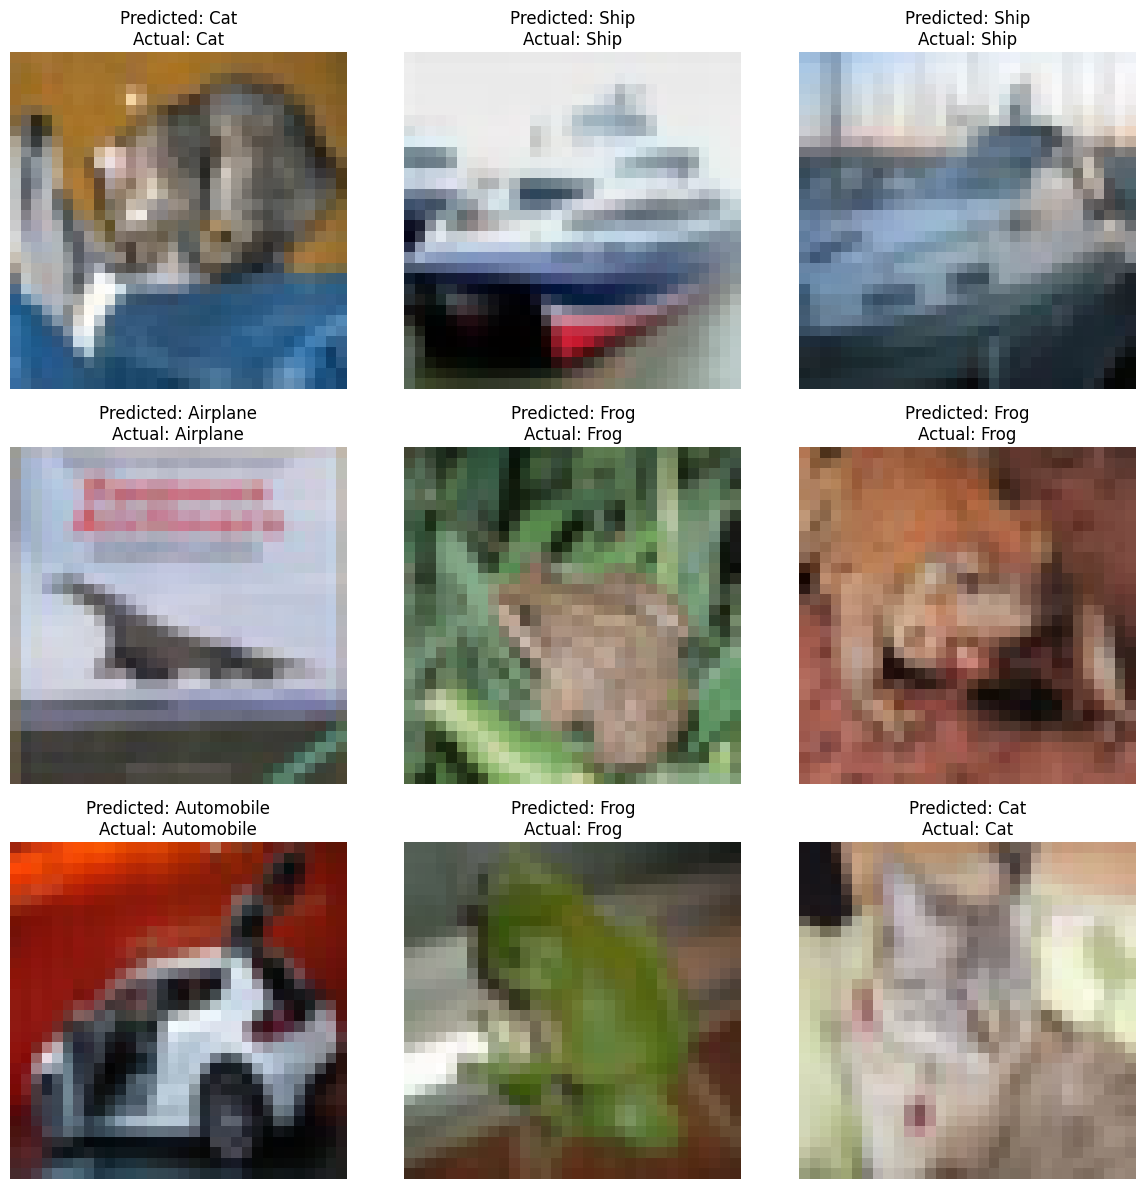

In [ ]:
# Making Sample Predictions
plt.figure(figsize=(12,12))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(x_test[i])

    pred_label = class_names[predicted_classes[i]]
    true_label = class_names[true_classes[i]]

    plt.title(f"Predicted: {pred_label}\nActual: {true_label}")

    plt.axis('off')

plt.tight_layout()

plt.show()


In [ ]:
# saving model

model.save("improved_cctv_cnn_model.h5")

print("\nModel Saved Successfully!")


Model Saved Successfully!
